# Financial Analysis

Cost, selling price, and margin patterns after joining client and translator rate information.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "agents.md").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate project root from notebook directory.")
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 120
pd.options.display.max_rows = 50

from data_analysis._shared.eda_utils import (
    ENRICHED_PATH,
    FEATURE_GROUPS,
    NUMERIC_OUTLIER_COLUMNS,
    build_enriched_tasks,
    categorical_variants,
    cross_sheet_consistency_report,
    detect_outliers,
    diagnose_client_unmatched,
    diagnose_pair_unmatched,
    diagnose_schedule_unmatched,
    dtype_audit,
    exact_duplicates,
    join_datasets,
    load_all_data,
    load_enriched_tasks,
    missing_summary,
    missingness_by_group,
    missingness_correlation,
    near_duplicates_data,
    proofread_reviewer_comparison,
    same_language_examples,
    same_language_report,
    set_plot_style,
    sheet_dimensions_report,
    summarize_join_integrity,
    timestamp_logic_report,
    timestamp_violation_samples,
    translator_on_time_summary,
    translator_quality_summary,
    wilson_interval,
    zero_value_report,
)

set_plot_style()
sheets = load_all_data()
data = sheets["data"]
schedules = sheets["schedules"]
clients = sheets["clients"]
pairs = sheets["pairs"]
print(f"Loaded Data={data.shape}, Schedules={schedules.shape}, Clients={clients.shape}, Pairs={pairs.shape}")

Loaded Data=(997933, 29), Schedules=(983, 11), Clients=(2645, 6), Pairs=(4688, 7)


,task_hourly_rate,selling_hourly_price,pair_hourly_rate
count,997926.000000,997933.000000,997926.000000
mean,17.060431,32.798119,17.060431
std,4.231651,9.202740,4.231651
min,8.000000,20.000000,8.000000
25%,15.000000,25.000000,15.000000
50%,16.000000,35.000000,16.000000
75%,18.000000,40.000000,18.000000
max,62.000000,50.000000,62.000000


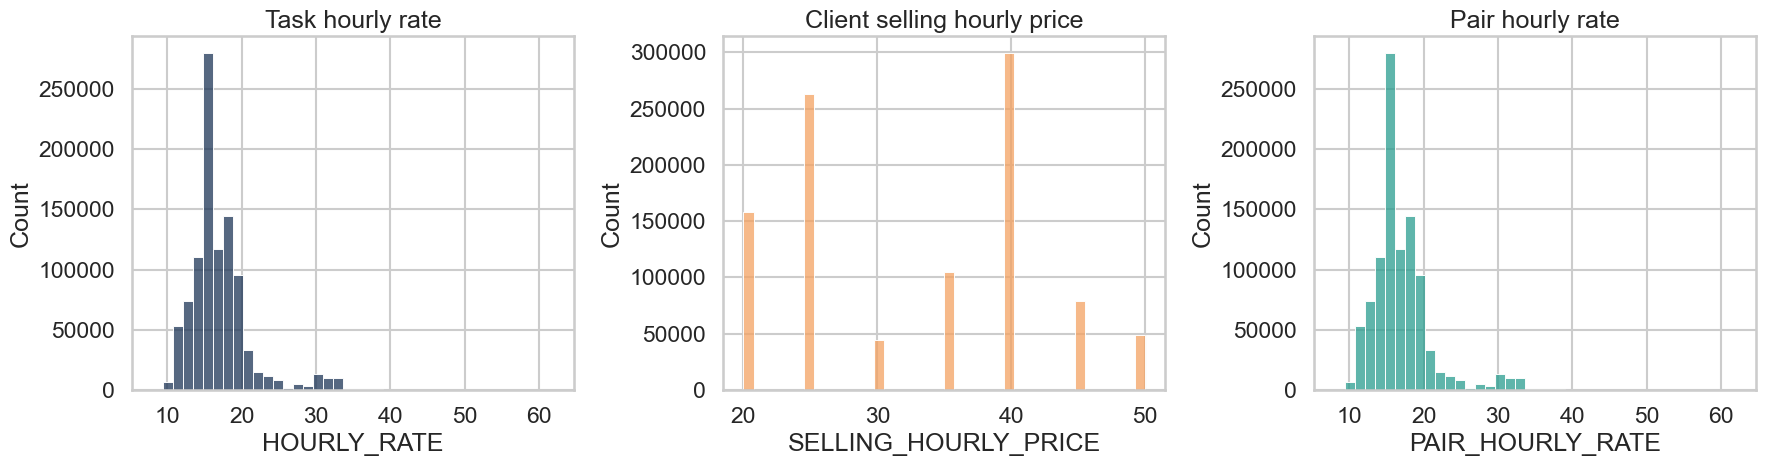

In [2]:
enriched = load_enriched_tasks()
display(
    pd.DataFrame(
        {
            "task_hourly_rate": enriched["HOURLY_RATE"].describe(),
            "selling_hourly_price": enriched["SELLING_HOURLY_PRICE"].describe(),
            "pair_hourly_rate": enriched["PAIR_HOURLY_RATE"].describe(),
        }
    )
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(enriched["HOURLY_RATE"].dropna(), bins=40, ax=axes[0], color="#1d3557")
axes[0].set_title("Task hourly rate")
sns.histplot(enriched["SELLING_HOURLY_PRICE"].dropna(), bins=40, ax=axes[1], color="#f4a261")
axes[1].set_title("Client selling hourly price")
sns.histplot(enriched["PAIR_HOURLY_RATE"].dropna(), bins=40, ax=axes[2], color="#2a9d8f")
axes[2].set_title("Pair hourly rate")
plt.tight_layout()
plt.show()

,task_rate_margin,pair_rate_margin
count,997926.000000,997926.000000
mean,25.229407,25.229407
std,109.767546,109.767546
min,-4178.160000,-4178.160000
25%,0.570000,0.570000
50%,3.400000,3.400000
75%,13.500000,13.500000
max,7975.000000,7975.000000


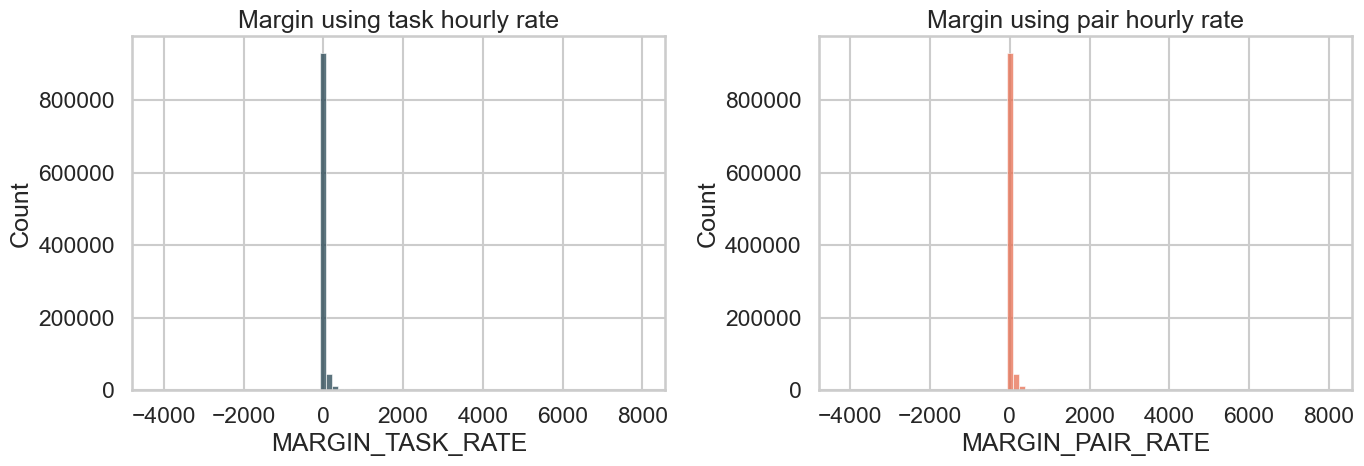

,metric,value
0,Loss-making tasks by pair-rate margin (%),4.32


In [3]:
margin_summary = pd.DataFrame(
    {
        "task_rate_margin": enriched["MARGIN_TASK_RATE"].describe(),
        "pair_rate_margin": enriched["MARGIN_PAIR_RATE"].describe(),
    }
)
display(margin_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(enriched["MARGIN_TASK_RATE"].dropna(), bins=80, ax=axes[0], color="#264653")
axes[0].set_title("Margin using task hourly rate")
sns.histplot(enriched["MARGIN_PAIR_RATE"].dropna(), bins=80, ax=axes[1], color="#e76f51")
axes[1].set_title("Margin using pair hourly rate")
plt.tight_layout()
plt.show()

loss_rate = (enriched["MARGIN_PAIR_RATE"] < 0).mean() * 100
display(pd.DataFrame([{"metric": "Loss-making tasks by pair-rate margin (%)", "value": round(loss_rate, 2)}]))

In [4]:
pair_margin = (
    enriched.assign(language_pair=enriched["SOURCE_LANG"] + " -> " + enriched["TARGET_LANG"])
    .groupby("language_pair")
    .agg(tasks=("TASK_ID", "size"), avg_margin=("MARGIN_PAIR_RATE", "mean"))
    .query("tasks >= 50")
    .sort_values("avg_margin", ascending=False)
    .reset_index()
)
display(pair_margin.head(20))
display(pair_margin.tail(20))

,language_pair,tasks,avg_margin
0,Spanish (LA) -> Spanish (Iberian),50,271.029000
1,Portuguese (Brazil) -> English,119,263.977563
2,Spanish (Iberian) -> Russian,141,190.455887
3,French -> Spanish (LA),69,175.261159
4,Spanish (Global) -> Quiche,318,169.319528
5,Italian -> Spanish (Iberian),180,147.251333
6,German -> Spanish (Mexico),55,106.682000
7,Catalan -> Spanish (Iberian),290,83.286276
8,Spanish (Iberian) -> English (UK),164,73.120366
9,Spanish (Global) -> Portuguese (Iberian),54,68.592037


,language_pair,tasks,avg_margin
56,Spanish (Global) -> German,66,3.084091
57,English -> Arabic,61,0.801475
58,English -> Basque,33918,0.197453
59,English -> Chinese (Simplified),79,-2.024684
60,English -> French,2020,-3.339262
61,English -> Italian,1682,-3.446290
62,English -> Quechua,9780,-7.429769
63,Spanish (Global) -> Quechua,77,-14.540130
64,English -> German,496,-18.433367
65,English -> Polish,198,-22.988333


In [5]:
client_financials = (
    enriched.groupby("MANUFACTURER")
    .agg(
        tasks=("TASK_ID", "size"),
        revenue=("COST", "sum"),
        avg_margin=("MARGIN_PAIR_RATE", "mean"),
        total_margin=("MARGIN_PAIR_RATE", "sum"),
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)
display(client_financials.head(20))
display(client_financials.sort_values("total_margin", ascending=False).head(20))

,MANUFACTURER,tasks,revenue,avg_margin,total_margin
0,AeroSysTech,167992,4931225.22,10.525920,1768270.28
1,TrueConnect,258435,2965878.75,15.850092,4096218.45
2,FrontierTech,66657,1483026.39,5.861806,390730.41
3,MotorForge,11451,1148190.93,188.335457,2156629.32
4,HealthyLife,20250,1054281.12,10.616152,214977.08
5,NextGen Industries,46321,992119.07,27.090277,1254848.73
6,Flux Fuel,4244,372219.53,37.107439,157483.97
7,MindSpark Media,12240,363958.19,20.826471,254916.01
8,NexisOne,13134,332975.81,3.838449,50414.19
9,QuantumLogic,10184,332483.94,31.503835,320835.06


,MANUFACTURER,tasks,revenue,avg_margin,total_margin
1,TrueConnect,258435,2965878.75,15.850092,4096218.45
3,MotorForge,11451,1148190.93,188.335457,2156629.32
0,AeroSysTech,167992,4931225.22,10.525920,1768270.28
5,NextGen Industries,46321,992119.07,27.090277,1254848.73
11,Innovate Industries,2268,268543.28,191.385150,434061.52
2,FrontierTech,66657,1483026.39,5.861806,390730.41
14,VidaCore Biotech,6107,225475.15,62.690673,382789.25
17,InduNet Solutions,19881,208449.05,18.212854,362089.75
9,QuantumLogic,10184,332483.94,31.503835,320835.06
15,SmartMed Innovations,8527,218481.89,34.210644,291714.16


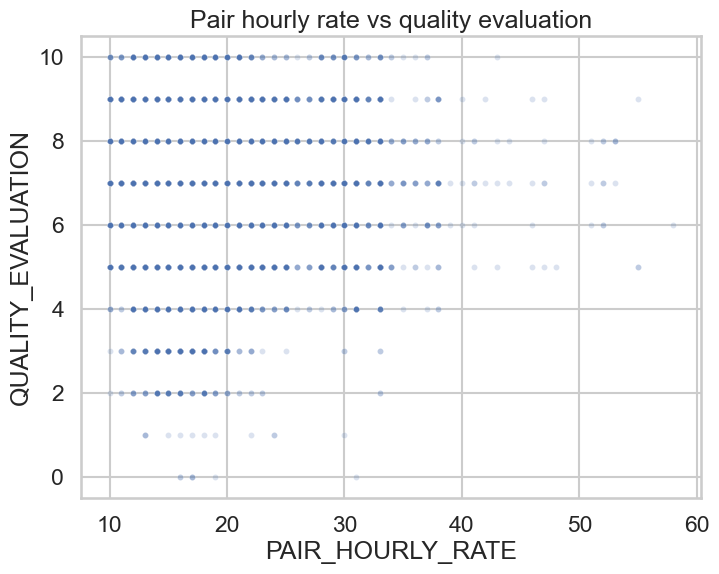

,metric,value
0,Correlation: pair hourly rate vs quality,-0.014
1,Correlation: task hourly rate vs quality,-0.014


In [6]:
quality_scatter = enriched[["PAIR_HOURLY_RATE", "HOURLY_RATE", "QUALITY_EVALUATION"]].dropna().sample(30000, random_state=42)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=quality_scatter, x="PAIR_HOURLY_RATE", y="QUALITY_EVALUATION", alpha=0.2, s=18)
plt.title("Pair hourly rate vs quality evaluation")
plt.show()

corr_pair_quality = quality_scatter["PAIR_HOURLY_RATE"].corr(quality_scatter["QUALITY_EVALUATION"])
corr_task_quality = quality_scatter["HOURLY_RATE"].corr(quality_scatter["QUALITY_EVALUATION"])
display(
    pd.DataFrame(
        [
            {"metric": "Correlation: pair hourly rate vs quality", "value": round(corr_pair_quality, 3)},
            {"metric": "Correlation: task hourly rate vs quality", "value": round(corr_task_quality, 3)},
        ]
    )
)

In [7]:
zero_financial = enriched.loc[(enriched["HOURS"].fillna(0) == 0) | (enriched["COST"].fillna(0) == 0)].copy()
display(
    zero_financial.groupby("TASK_TYPE_CLEAN")
    .agg(
        rows=("TASK_ID", "size"),
        hours=("HOURS", "sum"),
        cost=("COST", "sum"),
        avg_margin=("MARGIN_PAIR_RATE", "mean"),
    )
    .sort_values("rows", ascending=False)
)

,rows,hours,cost,avg_margin
TASK_TYPE_CLEAN,,,,
ProofReading,49972,0.16,0.0,0.0
Miscellaneous,11310,1.17,0.0,0.0
Translation,5685,4.04,0.0,0.0
PostEditing,922,0.00,0.0,0.0
Engineering,861,0.00,0.0,0.0
LanguageLead,187,0.00,0.0,0.0
Management,47,0.00,0.0,0.0
TEST,29,0.00,0.0,0.0
DTP,26,0.00,0.0,0.0
